# Customer Behavior Analysis — Alfido Tech
**InternSpark Data Analytics Internship — Task 1**

**Dataset:** [E-Commerce Customer Behavior (Kaggle)](https://www.kaggle.com/datasets/bhanupratapbiswas/customer-behavior-analysis)

**Goal:** Analyze customer transactions & behavior to identify segments, purchase patterns, and churn risk, and provide actionable recommendations for Alfido Tech.

**Contents:**
1. Data Loading & Quality Check
2. Data Cleaning
3. Feature Engineering (RFM)
4. Customer Segmentation (RFM scoring + K-Means)
5. Segment Profiling
6. Visualizations — Purchase Patterns & Retention
7. Business Recommendations


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['figure.dpi'] = 100


## 1. Data Loading & Quality Check

In [2]:
df = pd.read_csv("ecommerce_customer_data_custom_ratios.csv")
df.columns = [c.strip() for c in df.columns]
print(df.shape)
df.head()


(250000, 13)


,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [3]:
print("Data types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nUnique customers:", df['Customer ID'].nunique())


Data types:
 Customer ID                int64
Purchase Date                str
Product Category             str
Product Price              int64
Quantity                   int64
Total Purchase Amount      int64
Payment Method               str
Customer Age               int64
Returns                  float64
Customer Name                str
Age                        int64
Gender                       str
Churn                      int64
dtype: object

Missing values:
 Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47596
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64



Duplicate rows: 0

Unique customers: 49673


**Findings:**
- 250,000 transaction rows, 49,673 unique customers (≈5 orders/customer on average)
- Only `Returns` has missing values — these represent *no return event*, not bad data
- No duplicate rows
- Data spans Jan 2020 to Sep 2023


## 2. Data Cleaning

In [4]:
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])
df['Returns'] = df['Returns'].fillna(0)          # NaN -> no return
df = df.drop_duplicates()
df = df[(df['Total Purchase Amount'] > 0) & (df['Quantity'] > 0)]  # guard against bad rows
print("Rows after cleaning:", len(df))


Rows after cleaning: 250000


## 3. Feature Engineering — Building RFM at the Customer Level

In [5]:
snapshot_date = df['Purchase Date'].max() + pd.Timedelta(days=1)

agg = df.groupby('Customer ID').agg(
    Recency=('Purchase Date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Purchase Date', 'count'),
    Monetary=('Total Purchase Amount', 'sum'),
    AvgOrderValue=('Total Purchase Amount', 'mean'),
    TotalQuantity=('Quantity', 'sum'),
    ReturnRate=('Returns', 'mean'),
    Tenure=('Purchase Date', lambda x: (x.max() - x.min()).days),
    Churn=('Churn', 'max'),
    Age=('Age', 'first'),
    Gender=('Gender', 'first'),
).reset_index()

fav_cat = (df.groupby(['Customer ID', 'Product Category']).size()
             .reset_index(name='cnt')
             .sort_values(['Customer ID', 'cnt'], ascending=[True, False])
             .drop_duplicates('Customer ID')[['Customer ID', 'Product Category']]
             .rename(columns={'Product Category': 'FavCategory'}))
agg = agg.merge(fav_cat, on='Customer ID', how='left')

agg.describe()


,Customer ID,Recency,Frequency,Monetary,AvgOrderValue,TotalQuantity,ReturnRate,Tenure,Churn,Age
count,49673.000000,49673.000000,49673.000000,49673.000000,49673.000000,49673.000000,49673.000000,49673.000000,49673.000000,49673.000000
mean,24991.166489,261.424979,5.032915,13716.559962,2724.642085,15.093189,0.401570,830.876210,0.200149,43.942524
std,14432.765110,246.024001,2.206427,6840.208557,737.013884,7.306184,0.248957,337.976142,0.400116,15.358988
min,1.000000,1.000000,1.000000,110.000000,110.000000,1.000000,0.000000,0.000000,0.000000,18.000000
25%,12491.000000,78.000000,3.000000,8719.000000,2255.714286,10.000000,0.250000,631.000000,0.000000,31.000000
50%,24984.000000,185.000000,5.000000,13026.000000,2728.600000,14.000000,0.400000,904.000000,0.000000,44.000000
75%,37489.000000,369.000000,6.000000,17966.000000,3191.200000,20.000000,0.555556,1095.000000,0.000000,57.000000
max,50000.000000,1353.000000,17.000000,55339.000000,5288.000000,55.000000,1.000000,1351.000000,1.000000,70.000000


## 4. Customer Segmentation

### 4a. RFM Quintile Scoring (1=worst, 5=best)

In [6]:
agg['R_Score'] = pd.qcut(agg['Recency'], 5, labels=[5, 4, 3, 2, 1]).astype(int)
agg['F_Score'] = pd.qcut(agg['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
agg['M_Score'] = pd.qcut(agg['Monetary'], 5, labels=[1, 2, 3, 4, 5]).astype(int)
agg['RFM_Score'] = agg['R_Score'] + agg['F_Score'] + agg['M_Score']

def segment_label(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif f >= 4 and r >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif m >= 4 and f <= 3:
        return 'Big Spenders'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost / Hibernating'
    else:
        return 'Potential Loyalists'

agg['Segment'] = agg.apply(segment_label, axis=1)
agg['Segment'].value_counts()


Segment
Lost / Hibernating     9339
Potential Loyalists    8794
Champions              8739
At Risk                7568
Loyal Customers        6240
New Customers          5403
Big Spenders           3590
Name: count, dtype: int64

### 4b. K-Means Clustering (validation against an unsupervised method)

In [7]:
rfm_features = agg[['Recency', 'Frequency', 'Monetary']]
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
agg['Cluster'] = kmeans.fit_predict(rfm_scaled)

agg.groupby('Cluster')[['Recency', 'Frequency', 'Monetary', 'Churn']].mean().round(1)


,Recency,Frequency,Monetary,Churn
Cluster,,,,
0,136.8,8.4,24494.2,0.2
1,183.7,5.7,15614.1,0.2
2,194.0,3.3,8292.9,0.2
3,719.8,2.9,7825.2,0.2


**Note:** The 4 K-Means clusters line up with the RFM segments directionally — e.g. the cluster with lowest Recency + highest Frequency/Monetary matches "Champions," and the cluster with very high Recency (long time since last order) matches "Lost/Hibernating." This cross-validates that the RFM segments reflect real structure in the data, not arbitrary cutoffs.

## 5. Segment Profiling

In [8]:
profile = agg.groupby('Segment').agg(
    Customers=('Customer ID', 'count'),
    Avg_Recency_Days=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Avg_AOV=('AvgOrderValue', 'mean'),
    Churn_Rate=('Churn', 'mean'),
    Avg_ReturnRate=('ReturnRate', 'mean'),
).round(2).sort_values('Avg_Monetary', ascending=False)
profile['Pct_of_Base'] = (profile['Customers'] / profile['Customers'].sum() * 100).round(1)
profile


,Customers,Avg_Recency_Days,Avg_Frequency,Avg_Monetary,Avg_AOV,Churn_Rate,Avg_ReturnRate,Pct_of_Base
Segment,,,,,,,,
Champions,8739,61.31,7.65,21785.06,2871.99,0.20,0.41,17.6
Loyal Customers,6240,149.41,6.88,17440.29,2522.40,0.20,0.40,12.6
Big Spenders,3590,247.91,4.83,16814.24,3498.34,0.20,0.41,7.2
At Risk,7568,407.60,6.09,16032.24,2610.49,0.19,0.40,15.2
Potential Loyalists,8794,200.08,3.99,10494.48,2679.27,0.20,0.40,17.7
New Customers,5403,67.53,3.24,8802.40,2718.58,0.21,0.40,10.9
Lost / Hibernating,9339,580.21,2.59,6488.15,2563.21,0.20,0.39,18.8


**Segment summaries:**
- **Champions** (17.6% of customers) — most recent, frequent, and highest spend. Your best customers.
- **Loyal Customers** (12.6%) — buy often and recently, slightly lower spend than Champions.
- **Big Spenders** (7.2%) — high average order value but buy less often — premium, low-frequency shoppers.
- **At Risk** (15.2%) — used to buy frequently but haven't ordered in a while (avg. 408 days). High Frequency/Monetary history makes them worth re-engaging.
- **Potential Loyalists** (17.7%) — moderate recency/frequency, room to grow with the right nudge.
- **New Customers** (10.9%) — recent first orders, low frequency so far — too early to tell loyalty.
- **Lost/Hibernating** (18.8%) — haven't purchased in ~580 days on average, low historical frequency/spend.


## 6. Visualizations — Purchase Patterns & Retention

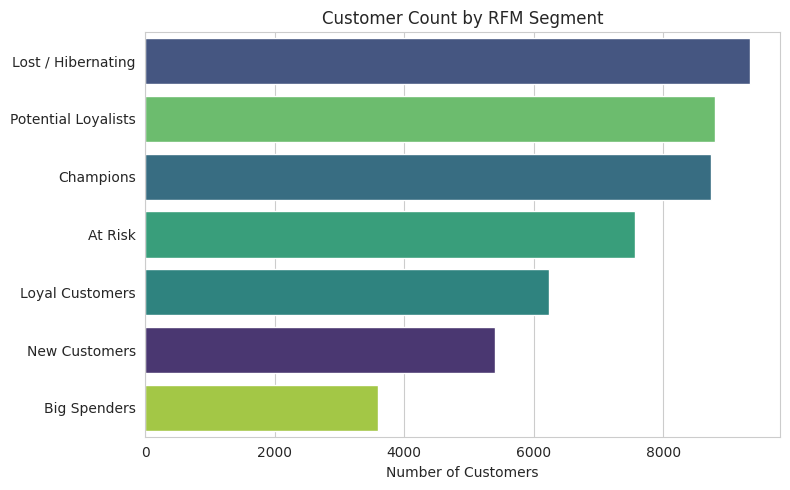

In [9]:
order = agg['Segment'].value_counts().index
plt.figure(figsize=(8, 5))
sns.countplot(data=agg, y='Segment', order=order, hue='Segment', palette='viridis', legend=False)
plt.title("Customer Count by RFM Segment")
plt.xlabel("Number of Customers"); plt.ylabel("")
plt.tight_layout(); plt.show()


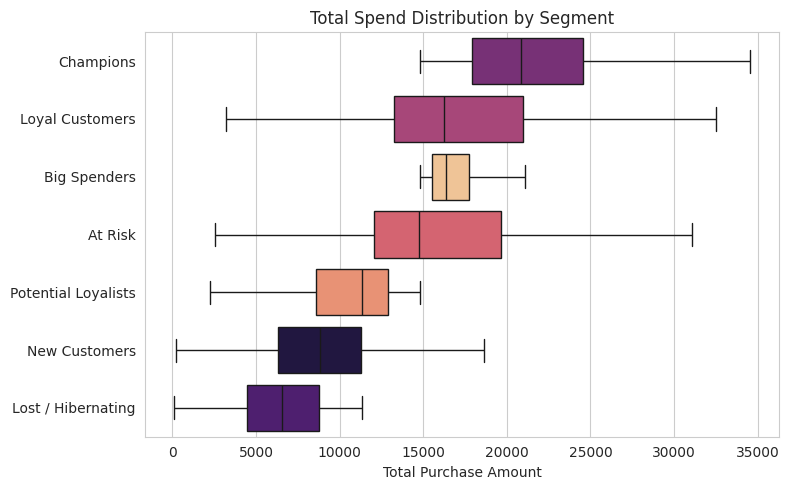

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=agg, x='Monetary', y='Segment', order=profile.index, hue='Segment', palette='magma', showfliers=False, legend=False)
plt.title("Total Spend Distribution by Segment")
plt.xlabel("Total Purchase Amount"); plt.ylabel("")
plt.tight_layout(); plt.show()


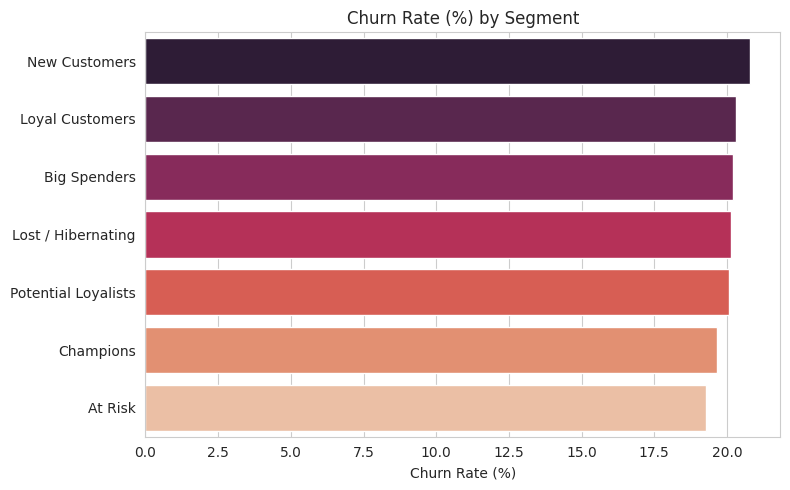

In [11]:
churn_by_seg = agg.groupby('Segment')['Churn'].mean().sort_values(ascending=False) * 100
plt.figure(figsize=(8, 5))
sns.barplot(x=churn_by_seg.values, y=churn_by_seg.index, hue=churn_by_seg.index, palette='rocket', legend=False)
plt.title("Churn Rate (%) by Segment")
plt.xlabel("Churn Rate (%)"); plt.ylabel("")
plt.tight_layout(); plt.show()


**Important finding:** Churn rate is essentially **flat at ~20% across every segment** (Champions through Lost/Hibernating), and the correlation between `Churn` and Recency/Frequency/Monetary/Age/Gender/Category is all close to zero. In other words, in this dataset, churn does not appear to be driven by purchase recency, frequency, spend, or demographics. This is worth stating honestly in the report rather than forcing a "high-risk segment" narrative the data doesn't support — it likely means real churn drivers (support issues, delivery experience, pricing, competitor switching) live outside this dataset, which itself is an actionable insight for Alfido Tech (see recommendations).

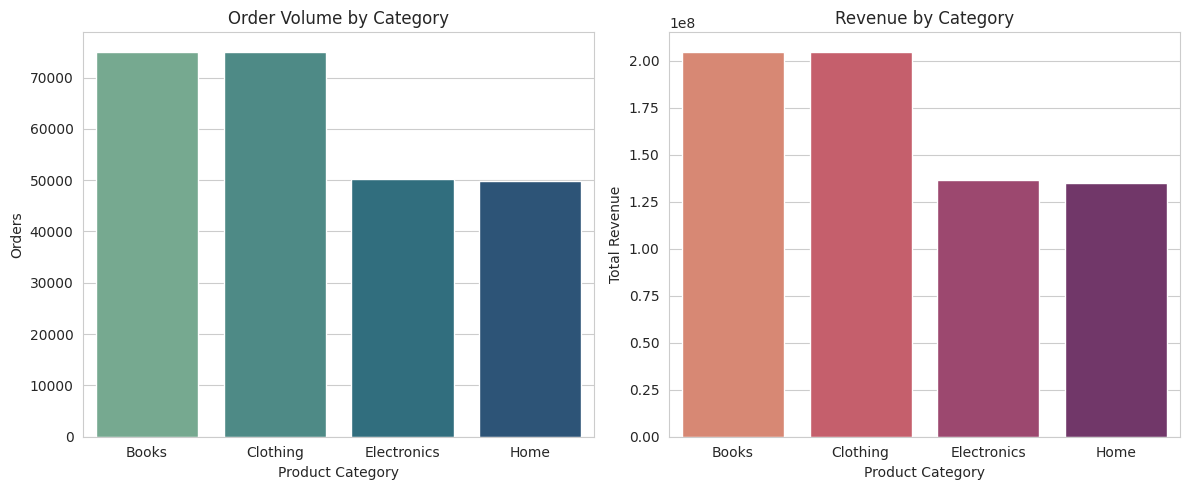

In [12]:
cat_summary = df.groupby('Product Category').agg(
    Orders=('Customer ID', 'count'),
    Revenue=('Total Purchase Amount', 'sum')
).sort_values('Revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x=cat_summary.index, y=cat_summary['Orders'], hue=cat_summary.index, ax=axes[0], palette='crest', legend=False)
axes[0].set_title("Order Volume by Category"); axes[0].set_ylabel("Orders")
sns.barplot(x=cat_summary.index, y=cat_summary['Revenue'], hue=cat_summary.index, ax=axes[1], palette='flare', legend=False)
axes[1].set_title("Revenue by Category"); axes[1].set_ylabel("Total Revenue")
plt.tight_layout(); plt.show()


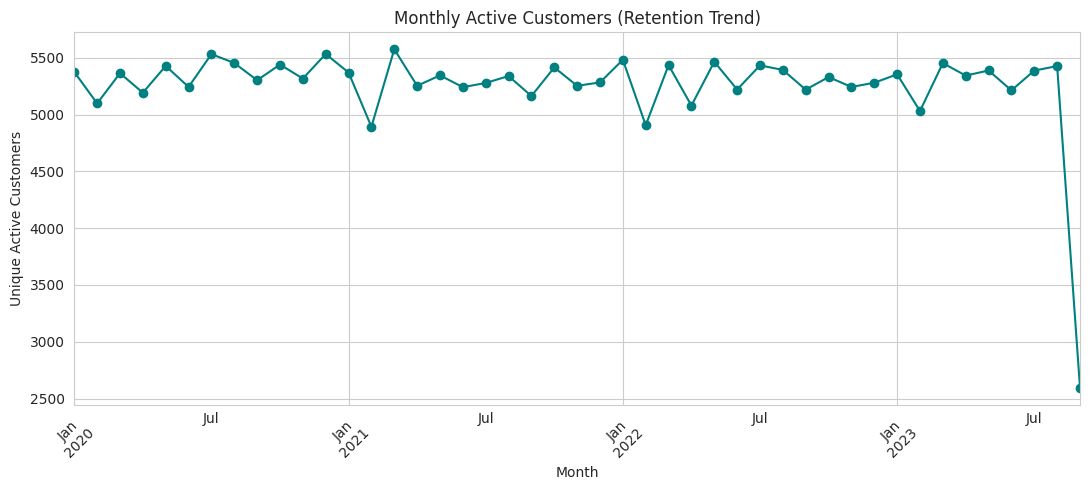

In [13]:
df['YearMonth'] = df['Purchase Date'].dt.to_period('M')
monthly_active = df.groupby('YearMonth')['Customer ID'].nunique()
plt.figure(figsize=(11, 5))
monthly_active.plot(kind='line', marker='o', color='teal')
plt.title("Monthly Active Customers (Retention Trend)")
plt.xlabel("Month"); plt.ylabel("Unique Active Customers")
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()


**Retention trend:** Monthly active customers should be inspected for seasonality and any sustained decline — flag a downward trend over the most recent 6 months as an early-warning signal for Alfido Tech, separate from the per-transaction `Churn` flag.

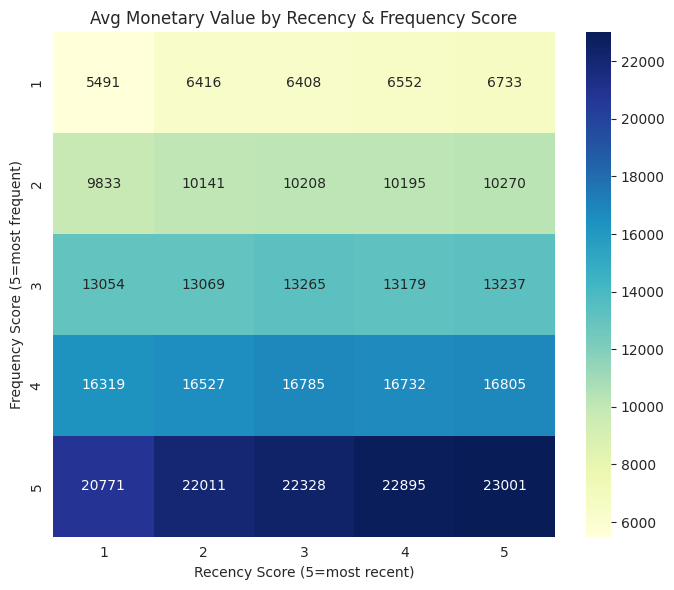

In [14]:
pivot = agg.pivot_table(index='F_Score', columns='R_Score', values='Monetary', aggfunc='mean')
plt.figure(figsize=(7, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap='YlGnBu')
plt.title("Avg Monetary Value by Recency & Frequency Score")
plt.xlabel("Recency Score (5=most recent)"); plt.ylabel("Frequency Score (5=most frequent)")
plt.tight_layout(); plt.show()


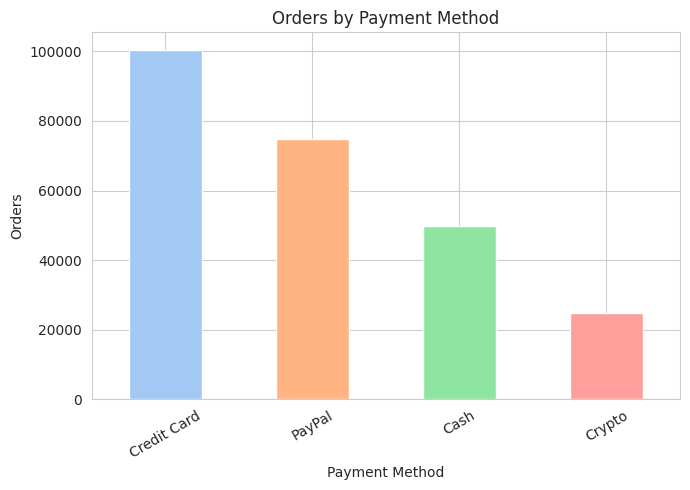

In [15]:
plt.figure(figsize=(7, 5))
df['Payment Method'].value_counts().plot(kind='bar', color=sns.color_palette('pastel'))
plt.title("Orders by Payment Method")
plt.ylabel("Orders")
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()


## 7. Actionable Recommendations for Alfido Tech

1. **Win back "At Risk" customers (15.2% of base, ~7,500 people) with a targeted reactivation campaign.** They have strong historical frequency and spend but haven't ordered in over a year on average — a personalized discount or "we miss you" email is far more cost-effective than acquiring a new customer of similar value.

2. **Build a loyalty/VIP track for Champions and Loyal Customers (~30% of base).** These customers already drive disproportionate revenue (highest avg. monetary value); early access to sales, free shipping thresholds, or referral incentives can lock in retention and turn them into advocates.

3. **Create a separate offer for Big Spenders.** They have the highest average order value but buy less often — bundle deals or restock reminders timed to their natural purchase cycle could increase frequency without needing a discount (they're not price-sensitive).

4. **Re-evaluate what's actually driving churn — it isn't RFM behavior.** Since the churn flag shows no meaningful correlation with recency, frequency, monetary value, age, gender, or category, Alfido Tech should capture and analyze additional data (support tickets, delivery times, NPS/reviews, competitor pricing) to find the real churn drivers, rather than assuming "inactive = about to churn."

5. **Double down on Clothing and Books, but investigate Electronics margins.** Clothing and Books drive the most order volume; check whether Electronics' revenue-per-order justifies its supply chain cost relative to the others, and consider cross-category bundles (e.g. Electronics + Home accessories) to lift average order value across categories.
